In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%run '/content/pandas_missing_extension.ipynb'

In [3]:
titanic_df = sns.load_dataset('titanic')
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


<Axes: >

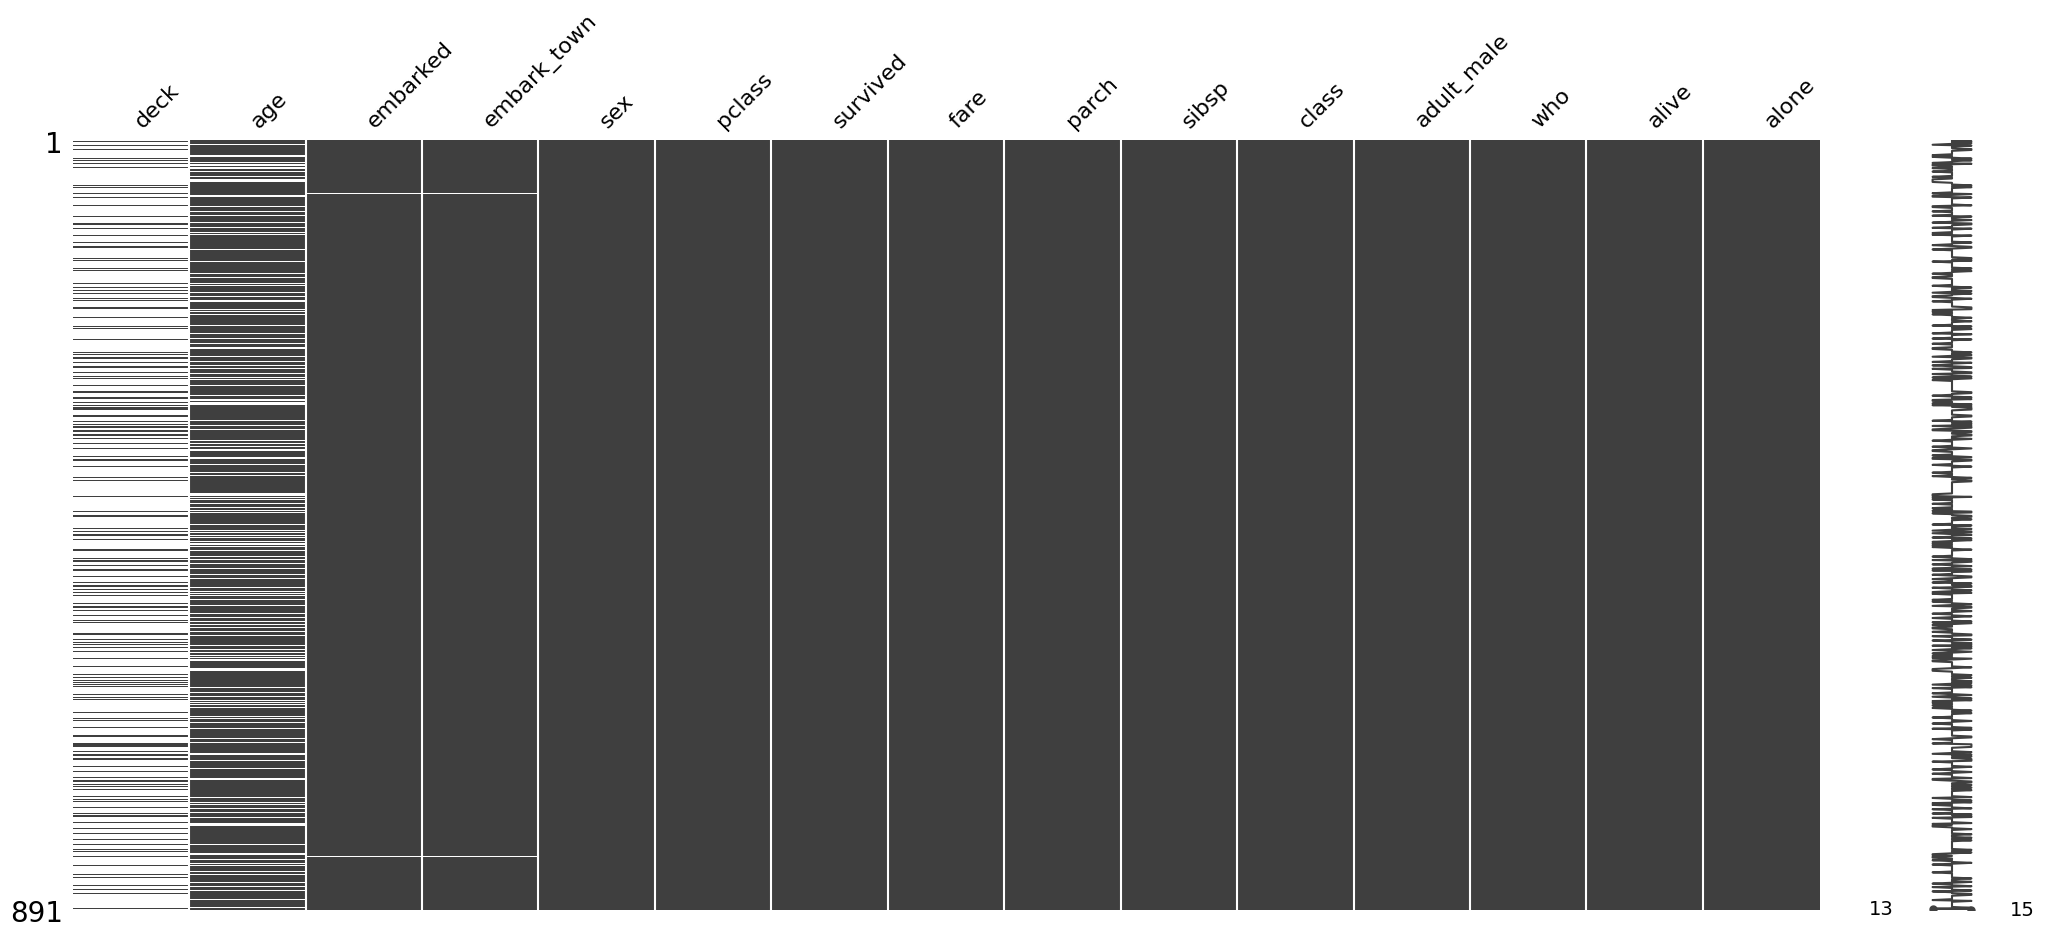

In [4]:
import missingno

titanic_df.missing.sort_variables_by_missingness().pipe(missingno.matrix)

# IMPUTACIÓN DE VARIABLES CATEGÓRICAS

In [5]:
titanic_df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


## IMPUTACIÓN POR PROPAGACIÓN HACIA ADELANTE Y HACIA ATRAS

In [6]:
data = pd.Series(['A',None,None,'B'])
data

,0
0,A
1,None
2,None
3,B


## FFILL()

In [7]:
data.ffill()

,0
0,A
1,A
2,A
3,B


# BFILL

In [8]:
data.bfill()

,0
0,A
1,B
2,B
3,B


## IMPUTAMOS LA VARIABLE DECK

In [9]:
df_deck = titanic_df.copy()
df_deck['deck'] = df_deck['deck'].ffill()
df_deck['deck'] = df_deck['deck'].bfill()
df_deck

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,C,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,B,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


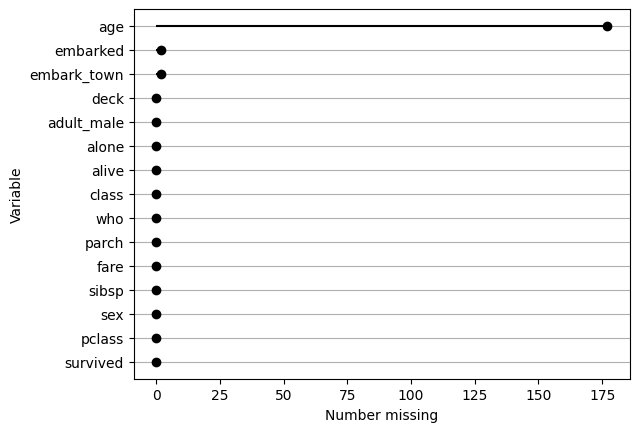

In [10]:
df_deck.missing.missing_variable_plot()

In [11]:
df_embark_town = df_deck.copy()
df_embark_town['embark_town'] = df_embark_town['embark_town'].ffill()
df_embark_town['embark_town'] = df_embark_town['embark_town'].bfill()

In [12]:
df_embarked = df_embark_town.copy()
df_embarked['embarked'] = df_embarked['embarked'].ffill()
df_embarked['embarked'] = df_embarked['embarked'].bfill()

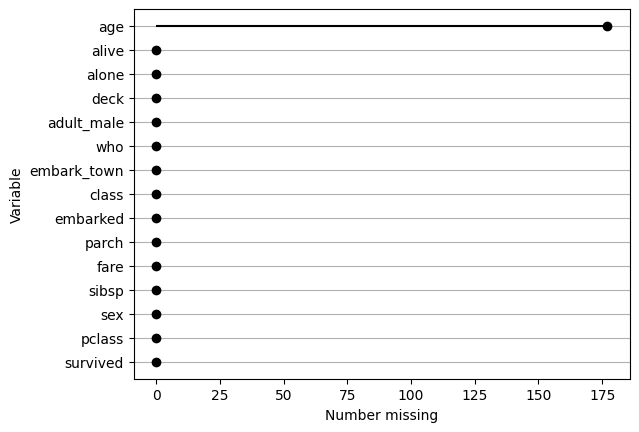

In [13]:
df_embarked.missing.missing_variable_plot()

In [14]:
df_clean = df_embarked.copy()
df_clean['age'] = df_clean['age'].fillna(round(df_embarked['age'].mean()))

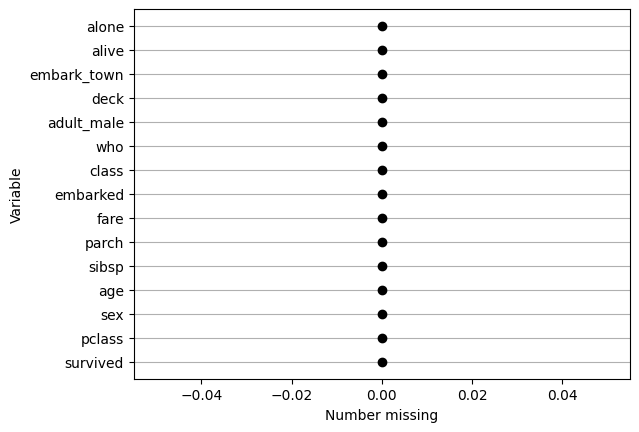

In [15]:
df_clean.missing.missing_variable_plot()

In [16]:
df_clean.to_csv('titanic_clean.csv',index=False)